# 01 · Understanding the dataset

**Purpose.** Before designing any agent we measured what the data actually says. Every design decision in
`CLAUDE.md` traces back to a number in this notebook.

**What you will see.** Each section states a question, runs the query that answers it, and then says what it means
for the agent. Nothing here is modelled or tuned; it is all direct measurement.

**How to run.** From `py/`: `uv sync`, then open this file in Jupyter or VS Code and *Run All*. The first run builds a
DuckDB cache from the 708 MB `transactions.csv` (about a minute); after that everything is fast.

**Hard rule.** Only the provided files are used. The original public IEEE-CIS files must never be used to recover outcomes.

## 1 · Setup

We use **DuckDB**: it reads CSV directly, is very fast for the window queries we need (bursts, recurring charges,
"what happened before this case opened"), and needs no server. `get_con()` keeps only the columns the analysis uses,
so the 393 anonymous Vesta columns do not slow every query.

In [1]:
import sys
sys.path.insert(0, "../src")            # so `import fraudpy` works from the notebooks folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fraudpy.data import get_con, DATA_DIR, ROOT

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.spines.top": False, "axes.spines.right": False})

con = get_con()                          # slim DuckDB tables, built once and cached in data/work.duckdb
q = lambda sql, *p: con.execute(sql, list(p)).df()   # run SQL, get a DataFrame
print("data folder:", DATA_DIR)

data folder: D:\Coding\hhg-task\Dataset


## 2 · The files

Five files, one join key. `transactions.csv` joins `identity.csv` on `TransactionID`. Identity exists only for online
transactions.

In [2]:
files = ["transactions.csv", "identity.csv", "closed_cases_history.csv", "case_pack.csv"]
sizes = pd.DataFrame({
    "file": files,
    "MB": [round((DATA_DIR / f).stat().st_size / 1e6, 1) for f in files],
    "rows": [q("select count(*) n from tx").n[0], q("select count(*) n from idn").n[0],
             q("select count(*) n from cc").n[0], q("select count(*) n from pack").n[0]],
})
sizes

,file,MB,rows
0,transactions.csv,707.9,590742
1,identity.csv,26.7,144432
2,closed_cases_history.csv,2.7,5565
3,case_pack.csv,0.0,20


## 3 · Time and channel

`ts` is the real timestamp (use it, not `TransactionDT`). `channel` is `in_person` for product `W` (no identity record) and
`online` for products C/H/R/S.

In [3]:
display(q("select min(ts) first_ts, max(ts) last_ts, count(distinct customer_id) customers from tx"))
display(q("select channel, prod, count(*) n, round(avg(risk_score),3) mean_score, round(median(amt),1) median_amt from tx group by 1,2 order by 1,2"))

,first_ts,last_ts,customers
0,2016-07-02 00:02:21,2016-12-31 23:58:54,13553


,channel,prod,n,mean_score,median_amt
0,in_person,W,439670,0.146,78.4
1,online,C,68721,0.197,31.3
2,online,H,33024,0.289,50.0
3,online,R,37699,0.305,125.0
4,online,S,11628,0.229,35.0


### The future is in the file

A case opens some hours *after* its flagged transaction, and the file keeps going to December 31. If the agent ever queried
without an upper time bound, it would see events that had not happened yet. **Every query in the agent takes `as_of = opened_at`.**

In [4]:
gap = q("""
    select p.case_id, p.trigger_type, t.ts as flagged_ts, p.opened_at,
           round(epoch(p.opened_at - t.ts) / 3600, 1) as hours_after_flagged_txn
    from pack p join tx t on t.TransactionID = p.flagged_txn_id order by 1
""")
print("hours between the flagged transaction and the case opening:")
print(gap.hours_after_flagged_txn.describe().round(1).to_string())
gap.head(5)

hours between the flagged transaction and the case opening:
count    20.0
mean      4.0
std       1.8
min       1.0
25%       3.0
50%       4.5
75%       6.0
max       6.0


,case_id,trigger_type,flagged_ts,opened_at,hours_after_flagged_txn
0,HHG-001,risk_score,2016-12-04 19:55:28,2016-12-05 01:55:28,6.0
1,HHG-002,risk_score,2016-11-22 17:27:07,2016-11-22 23:27:07,6.0
2,HHG-003,customer_report,2016-12-10 13:01:21,2016-12-10 15:01:21,2.0
3,HHG-004,customer_report,2016-12-29 01:53:54,2016-12-29 07:53:54,6.0
4,HHG-005,risk_score,2016-12-07 21:38:37,2016-12-08 03:38:37,6.0


## 4 · The closed cases (the only place the truth is written down)

4,665 confirmed fraud, 900 cleared. Patterns are the five documented ones plus `undocumented`. Cleared cases have pattern `none`.

In [5]:
q("""
    select outcome, pattern, count(*) cases, round(avg(exposure_usd),0) avg_exposure, round(avg(n_txns),1) avg_txns,
           sum(case when report_filed in ('Yes','True','true') then 1 else 0 end) reports_filed
    from cc group by 1,2 order by 1,3 desc
""")

,outcome,pattern,cases,avg_exposure,avg_txns,reports_filed
0,cleared,none,900,0.0,1.0,0.0
1,confirmed_fraud,card_not_present_fraud,1404,163.0,1.6,14.0
2,confirmed_fraud,account_takeover,1205,753.0,3.8,187.0
3,confirmed_fraud,card_not_present_new_device,1076,325.0,3.9,56.0
4,confirmed_fraud,out_of_region_use,955,583.0,2.6,124.0
5,confirmed_fraud,card_testing,16,1273.0,26.6,7.0
6,confirmed_fraud,undocumented,9,1171.0,3.3,9.0


In [6]:
q("select actions_taken, outcome, count(*) n from cc group by 1,2 order by 3 desc")

,actions_taken,outcome,n
0,CREATE_CASE|BLOCK_CARD,confirmed_fraud,4268
1,VERIFY_WITH_CUSTOMER|CLOSE_NO_FRAUD,cleared,900
2,CREATE_CASE|BLOCK_CARD|FILE_REPORT,confirmed_fraud,397


**Note for the agent.** Closed cases are *templated*: analyst notes are nearly identical within a pattern. Text similarity alone
would therefore be weak memory. The useful memory is **structural**: closed cases point at real transactions, cards and devices.

## 5 · The risk score is close to a decoy

The README warns the score is "often wrong in both directions". Here is how wrong. We label every transaction that belongs to a
closed case (`lab`), and compare the bank score for confirmed fraud, cleared cases, and everything with no case.

In [7]:
grp = q("""
    select coalesce(l.outcome, 'no_case') as group_, count(*) n,
           round(avg(t.risk_score),3) mean_score, round(quantile_cont(t.risk_score,0.5),3) median_score,
           round(avg((t.risk_score >= 0.7)::int),3) share_ge_070, round(avg((t.risk_score < 0.3)::int),3) share_lt_030,
           round(min(t.risk_score),2) min_score
    from tx t left join lab l on l.tid = t.TransactionID group by 1
""")
grp

,group_,n,mean_score,median_score,share_ge_070,share_lt_030,min_score
0,cleared,900,0.881,0.88,1.000,0.000,0.81
1,confirmed_fraud,14055,0.474,0.46,0.264,0.315,0.01
2,no_case,575787,0.163,0.11,0.023,0.858,0.01


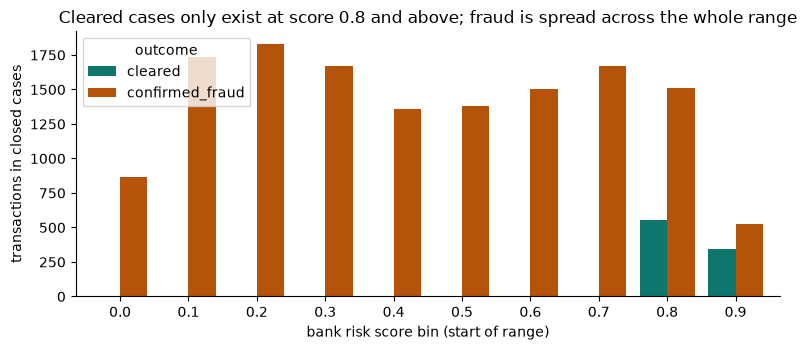

In [8]:
bins = q("""
    select floor(t.risk_score*10)/10 as bin, l.outcome, count(*) n
    from lab l join tx t on t.TransactionID = l.tid group by 1,2
""")
pv = bins.pivot(index="bin", columns="outcome", values="n").fillna(0)
ax = pv.plot(kind="bar", color={"confirmed_fraud": "#B45309", "cleared": "#0F766E"}, width=0.8)
ax.set_xlabel("bank risk score bin (start of range)"); ax.set_ylabel("transactions in closed cases")
ax.set_title("Cleared cases only exist at score 0.8 and above; fraud is spread across the whole range")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**What it means.**
- All 900 cleared cases scored at least 0.81. A score of 0.9 is where *innocence* lives, not just guilt.
- Confirmed fraud averages 0.47 and roughly a third of it scores under 0.3.
- So the score cannot be a threshold. It is one evidence class whose effect is learned, and it must be possible to clear a 0.9 and convict a 0.05.

## 6 · Why alerts were cleared

The analyst notes for cleared cases state the reason. Counting them tells the agent which *innocent explanations* it needs
to be able to test for.

In [9]:
cleared = q("select case_id, analyst_notes from cc where outcome = 'cleared'")
def reason(n):
    n = n.lower()
    if "travel" in n: return "travel to the billing region"
    if "new phone" in n: return "purchase from a new phone"
    if "unusual" in n: return "unusual amount, confirmed by customer"
    return "other"
cleared["reason"] = cleared.analyst_notes.map(reason)
r = cleared.reason.value_counts().to_frame("cases"); r["share"] = (r.cases / r.cases.sum()).round(3); r

,cases,share
reason,,
travel to the billing region,716,0.796
purchase from a new phone,158,0.176
"unusual amount, confirmed by customer",26,0.029


**What it means.** Three innocent explanations cover the history, and **every cleared case was triggered by the model score**. There is
no history of innocent *customer-report* cases, so policy rule R7 (a recurring charge the customer disputes) cannot be learned from memory.
It needs a rule-based test (recurring cadence with a coincidence check).

## 7 · Two undocumented patterns

The README says not every pattern is documented. Closed history contains nine cases marked `undocumented`. Reading them gives two patterns.

In [10]:
q("select case_id, n_txns, exposure_usd, analyst_notes from cc where pattern = 'undocumented' order by case_id")

,case_id,n_txns,exposure_usd,analyst_notes
0,CC-2649,3,390.04,Case CC-2649: cardholder C03528 reported 3 online purchase(s) they did not make. The p...
1,CC-2971,2,108.36,Case CC-2971: cardholder C09998 reported 2 online purchase(s) they did not make. The p...
2,CC-2985,3,381.40,Case CC-2985: cardholder C06617 reported 3 online purchase(s) they did not make. The p...
3,CC-3035,2,140.95,Case CC-3035: cardholder C09733 reported 2 online purchase(s) they did not make. The p...
4,CC-3748,4,1905.21,"Case CC-3748: cardholder C12267 reported four online purchases within forty minutes, e..."
5,CC-3841,4,1899.30,"Case CC-3841: cardholder C01099 reported four online purchases within forty minutes, e..."
6,CC-3907,4,1922.65,"Case CC-3907: cardholder C03060 reported four online purchases within forty minutes, e..."
7,CC-4086,4,1871.13,"Case CC-4086: cardholder C13269 reported four online purchases within forty minutes, e..."
8,CC-4124,4,1922.37,"Case CC-4124: cardholder C02838 reported four online purchases within forty minutes, e..."


### 7a · The device ring

The notes describe one device, behind an anonymous proxy, "never seen on this account", shared across cardholders. The device profile key
follows the README: `DeviceInfo | OS | browser | screen`. We find the fingerprint and look at how it behaves *over time* and *at what score*.

In [11]:
RING = "SM-G935F Build/NRD90M | Android 7.0 | chrome 62.0 for android | 1920x1080"
ring = q("""
    select t.TransactionID, t.customer_id, t.ts, t.amt, t.risk_score, d.id_15, d.id_23, l.case_id, l.pattern
    from idn d join tx t using (TransactionID) left join lab l on l.tid = t.TransactionID
    where d.dprof = ? and d.id_23 = 'IP_PROXY:ANONYMOUS'
""", RING)
print("fingerprint:", RING)
print("every row is New:", (ring.id_15 == "New").all(), "| transactions:", len(ring), "| customers:", ring.customer_id.nunique())
by_month = ring.assign(month=ring.ts.dt.to_period("M")).groupby("month").agg(
    txns=("TransactionID", "count"), customers=("customer_id", "nunique"), in_closed_cases=("case_id", "count"),
    min_score=("risk_score", "min"), max_score=("risk_score", "max"))
by_month

fingerprint: SM-G935F Build/NRD90M | Android 7.0 | chrome 62.0 for android | 1920x1080
every row is New: True | transactions: 114 | customers: 52


,txns,customers,in_closed_cases,min_score,max_score
month,,,,,
2016-08,44,22,6,0.01,0.37
2016-09,10,8,4,0.01,0.31
2016-11,50,28,0,0.01,0.44
2016-12,10,10,0,0.02,0.29


Nov-Dec: 60 transactions across 28 customers, scores 0.01 to 0.44, in any closed case: 0


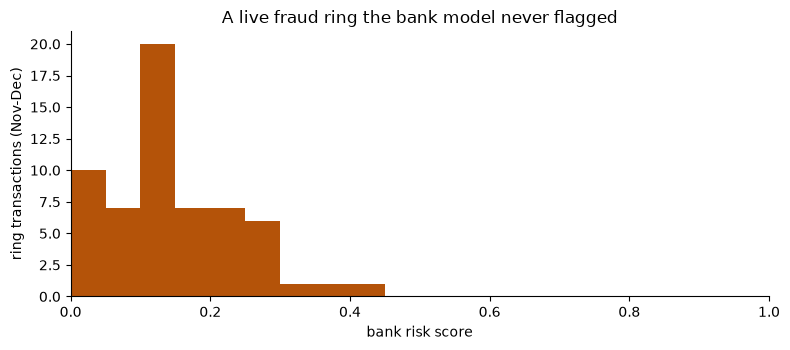

In [12]:
live = ring[ring.ts >= "2016-11-01"]
print(f"Nov-Dec: {len(live)} transactions across {live.customer_id.nunique()} customers, "
      f"scores {live.risk_score.min():.2f} to {live.risk_score.max():.2f}, in any closed case: {int(live.case_id.notna().sum())}")
fig, ax = plt.subplots()
ax.hist(live.risk_score, bins=np.arange(0, 1.05, 0.05), color="#B45309")
ax.set_xlim(0, 1); ax.set_xlabel("bank risk score"); ax.set_ylabel("ring transactions (Nov-Dec)")
ax.set_title("A live fraud ring the bank model never flagged"); plt.tight_layout(); plt.show()

**What it means.** These victims are invisible to a score-driven agent. The signal is the *fingerprint*: rare, always `New`, always behind an
anonymous proxy. Case **HHG-014** (an analyst request with score 0.05) belongs to this ring. The design needs a score-blind sweep that starts
from confirmed-fraud entities and weights devices by rarity, because generic devices (thousands of customers) are noise.

Check the rarity idea directly: how many customers share each device profile?

In [13]:
rarity = q("""
    select d.dprof, count(distinct t.customer_id) customers, count(*) txns
    from idn d join tx t using (TransactionID) group by 1
""")
print("device profiles:", len(rarity))
print(rarity.customers.describe(percentiles=[.5, .9, .99]).round(1).to_string())
print("ring fingerprint is shared by", int(rarity.loc[rarity.dprof == RING, "customers"].iloc[0]), "customers")
rarity.sort_values("customers", ascending=False).head(5)

device profiles:

 9706
count    9706.0
mean        7.0
std        30.4
min         1.0
50%         1.0
90%        10.0
99%       112.0
max      1011.0
ring fingerprint is shared by 52 customers


,dprof,customers,txns
1203,? | ? | ? | ?,1011,3648
7800,Windows | Windows 10 | chrome 63.0 | 1920x1080,842,2566
2390,? | ? | mobile safari generic | ?,697,4964
8420,Windows | ? | chrome 63.0 | ?,627,6353
3001,? | ? | mobile safari 11.0 | ?,600,3244


### 7c · How specific must a "ring" rule be?

A rule that calls a device profile a ring must not fire on ordinary devices. We test candidate rules against **every** device profile (not against any exam case). Per profile:
number of customers, share of uses marked `New`, and share behind an anonymous proxy.

In [14]:
prof = q("""
    select d.dprof, count(distinct t.customer_id) users, count(*) txns,
           avg((d.id_15 = 'New')::int) new_share, avg((d.id_23 = 'IP_PROXY:ANONYMOUS')::int) anon_share
    from idn d join tx t using (TransactionID) group by 1""")
rules = {
    "loose: 4+ users, New >= 0.7, and (proxy >= 0.5 or 8+ users)": (prof.users >= 4) & (prof.new_share >= 0.7) & ((prof.anon_share >= 0.5) | (prof.users >= 8)),
    "with proxy: 4+ users, New >= 0.7, proxy >= 0.5":               (prof.users >= 4) & (prof.new_share >= 0.7) & (prof.anon_share >= 0.5),
    "chosen: 5-200 users, New >= 0.9, proxy >= 0.8":                (prof.users >= 5) & (prof.users <= 200) & (prof.new_share >= 0.9) & (prof.anon_share >= 0.8),
}
print(f"{len(prof):,} device profiles in total; one documented ring\n")
print(pd.Series({k: int(m.sum()) for k, m in rules.items()}, name="profiles flagged").to_string())
print("\nwhat the chosen rule flags:")
prof[rules["chosen: 5-200 users, New >= 0.9, proxy >= 0.8"]].sort_values("txns", ascending=False)

9,706 device profiles in total; one documented ring

loose: 4+ users, New >= 0.7, and (proxy >= 0.5 or 8+ users)    212
with proxy: 4+ users, New >= 0.7, proxy >= 0.5                  15
chosen: 5-200 users, New >= 0.9, proxy >= 0.8                    2

what the chosen rule flags:


,dprof,users,txns,new_share,anon_share
9049,SM-G935F Build/NRD90M | Android 7.0 | chrome 62.0 for android | 1920x1080,52,114,1.0,1.0
7247,MacOS | Mac OS X 10_12 | safari generic | 1280x800,6,6,1.0,1.0


**What it means.** The loose rule flags over two hundred profiles, mostly generic iPhone profiles shared by hundreds of customers, which is background noise, not a ring. Requiring an anonymous proxy and an
almost-always-`New` pattern (what the closed ring cases actually describe) leaves the documented ring and a very small number of others. The backend uses the chosen rule
(`sharedRareFingerprint` in `backend/src/engines/signatures/index.ts`) and has tests for each of its conditions.

### 7b · Threshold structuring

The other notes: "four online purchases within forty minutes, each just under $500". We test that as a *window query*: three or more online
transactions between $400 and $500 on one customer inside an hour.

In [15]:
struct = q("""
    with s as (
      select t.*, count(*) over (partition by customer_id order by epoch(ts) range between 3600 preceding and current row) as w
      from tx t where channel = 'online' and amt between 400 and 499.99)
    select s.customer_id, min(s.ts) first_ts, count(*) txns, round(sum(amt),2) total, round(avg(risk_score),2) mean_score,
           any_value(l.case_id) closed_case, any_value(l.pattern) pattern
    from s left join lab l on l.tid = s.TransactionID where w >= 3 group by 1 order by first_ts
""")
struct["month"] = struct.first_ts.dt.to_period("M")
print(struct.groupby("month").agg(customers=("customer_id", "count"), in_closed_cases=("closed_case", "count")).to_string())
struct[struct.pattern == "undocumented"]

         customers  in_closed_cases
month                              
2016-07         16                1
2016-08          5                2
2016-09         12                5
2016-10          8                1
2016-11         10                0
2016-12          8                0


,customer_id,first_ts,txns,total,mean_score,closed_case,pattern,month
22,C12267,2016-09-20 15:20:00,2,936.97,0.23,CC-3748,undocumented,2016-09
23,C01099,2016-09-21 21:20:00,2,951.90,0.28,CC-3841,undocumented,2016-09
25,C03060,2016-09-24 11:21:00,2,983.56,0.06,CC-3907,undocumented,2016-09
28,C13269,2016-09-27 20:14:00,2,925.28,0.10,CC-4086,undocumented,2016-09
29,C02838,2016-09-28 09:12:00,3,1440.52,0.10,CC-4124,undocumented,2016-09


**What it means.** The closed structuring cases score low (0.04 to 0.38) and cluster in September; the exam period contains more customers with the same
shape (for example **HHG-006**). The agent needs a `threshold hugging` signature, and a generic novelty detector for the ones nobody has named.
Some heavy natural users also trip this query, which is why the signature is judged against the card's own baseline, not in isolation.

## 8 · A "customer" is not a person

`customer_id` is derived from the issuer field. Some customers have thousands of transactions, which no single person makes.

In [16]:
size = q("select customer_id, count(*) n from tx group by 1")
size["bucket"] = pd.cut(size.n, [0, 200, 1000, 3000, 10**9], labels=["<=200", "201-1000", "1001-3000", ">3000"])
s = size.groupby("bucket", observed=True).agg(customers=("customer_id", "count"), txns=("n", "sum"))
s["share_of_all_txns"] = (s.txns / s.txns.sum()).round(3); s

,customers,txns,share_of_all_txns
bucket,,,
<=200,13119,169446,0.287
201-1000,330,137167,0.232
1001-3000,78,130989,0.222
>3000,26,153140,0.259


**What it means.** About a hundred "customers" hold nearly half of all rows. Baselines like "this customer's usual amount" are meaningless for them.
The agent computes baselines **per card and per region**, and flags aggregate customers so their anomalies are down-weighted.

## 9 · Cards: the ID in the cases is not in the transactions

Cases refer to cards like `C01234-K2`, but `transactions.csv` has no card ID. We can resolve a card as
*(customer, network `card4`, type `card6`)*. Can we also reproduce the `K1`/`K2` numbering from card fields?

In [17]:
per_cust = q("""
    select n_cards, count(*) customers from (
      select customer_id, count(distinct coalesce(card4,'~') || '|' || coalesce(card6,'~')) n_cards from tx group by 1)
    group by 1 order by 1""")
display(per_cust)

con.execute("""create or replace temp table truth as
    select distinct cc.card_id, t.customer_id, coalesce(t.card4,'~') c4, coalesce(t.card6,'~') c6
    from lab l join cc using (case_id) join tx t on t.TransactionID = l.tid""")
con.execute("""create or replace temp table cand as
    with g as (select customer_id, coalesce(card4,'~') c4, coalesce(card6,'~') c6, count(*) n, min(ts) first_ts from tx group by 1,2,3)
    select *, row_number() over (partition by customer_id order by c6, c4) k_alpha,
              row_number() over (partition by customer_id order by n desc) k_volume,
              row_number() over (partition by customer_id order by first_ts) k_first from g""")
rules = {}
for k in ["k_alpha", "k_volume", "k_first"]:
    rules[k] = q(f"""select avg((t.card_id = c.customer_id || '-K' || c.{k})::int) match_rate, count(*) cards_tested
                    from truth t join cand c on c.customer_id = t.customer_id and c.c4 = t.c4 and c.c6 = t.c6""").iloc[0].round(3).to_dict()
pd.DataFrame(rules).T

,n_cards,customers
0,1,12793
1,2,755
2,3,5


,match_rate,cards_tested
k_alpha,0.799,1913.0
k_volume,0.797,1913.0
k_first,0.795,1913.0


**What it means.** No simple ordering rule reproduces the K labels (best is about 80%). So a `Card` vertex is keyed by (customer, network, type), and the
`Kn` label is kept as an **alias** learned from closed cases and the case pack. The answer files may only contain card IDs that exist in a source file,
so unresolved cards are described by their tuple in the evidence instead of being given an invented label.

## 10 · The 20 exam cases, using only what was known when each opened

For each case we compute the flagged transaction and the card's history **strictly before `opened_at`**: baseline amount, whether the product and region were
seen before, recent activity, and how widely the device profile is shared. These are observations to guide the design, **not verdicts**; there is no answer key.

In [18]:
def dossier(r):
    cust, as_of, tid = r.customer_id, r.opened_at, int(r.flagged_txn_id)
    ts, ch, prod, amt, addr1, c4, c6, rs = con.execute(
        "select ts, channel, prod, amt, addr1, card4, card6, risk_score from tx where TransactionID = ?", [tid]).fetchone()
    base = "customer_id = ? and coalesce(card4,'~') = ? and coalesce(card6,'~') = ? and ts <= ? and TransactionID <> ?"
    prm = [cust, c4 or "~", c6 or "~", as_of, tid]
    n, med, p95 = con.execute(f"select count(*), round(median(amt),1), round(quantile_cont(amt,0.95),1) from tx where {base}", prm).fetchone()
    prod_seen = con.execute(f"select count(*) from tx where {base} and prod = ?", prm + [prod]).fetchone()[0]
    reg_seen = con.execute(f"select count(*) from tx where {base} and addr1 = ?", prm + [addr1]).fetchone()[0] if addr1 is not None else None
    home = con.execute(f"select mode(addr1) from tx where {base} and channel = 'in_person'", prm).fetchone()[0]
    n48 = con.execute(f"select count(*) from tx where {base} and ts >= (?::timestamp - interval 48 hour)", prm + [as_of]).fetchone()[0]
    dv = con.execute("select dprof, id_15, id_23 from idn where TransactionID = ?", [tid]).fetchone()
    shared = con.execute("select count(distinct t.customer_id) from idn d join tx t using (TransactionID) where d.dprof = ? and t.ts <= ? and t.customer_id <> ?",
                         [dv[0], as_of, cust]).fetchone()[0] if dv else None
    return {"case": r.case_id, "trigger": r.trigger_type[:8], "score": rs, "channel": ch, "prod": prod, "amt": amt, "region": addr1, "home_region": home,
            "prior_txns": n, "median": med, "p95": p95, "amt_over_p95": (amt > p95) if p95 is not None else None,
            "prod_seen": prod_seen, "region_seen": reg_seen, "txns_48h": n48,
            "device_new": (dv[1] == "New") if dv else None, "proxy": (dv[2] or "") if dv else None, "device_shared_by": shared}

exam = pd.DataFrame([dossier(r) for r in q("select * from pack order by case_id").itertuples()])
exam

,case,trigger,score,channel,prod,amt,region,home_region,prior_txns,median,p95,amt_over_p95,prod_seen,region_seen,txns_48h,device_new,proxy,device_shared_by
0,HHG-001,risk_sco,0.61,in_person,W,77.07,444.0,512.0,359,83.9,381.4,False,357,10.0,8,None,NaN,NaN
1,HHG-002,risk_sco,0.79,online,C,292.36,NaN,NaN,35,47.3,91.4,True,35,NaN,0,None,NaN,NaN
2,HHG-003,customer,0.40,in_person,W,49.00,330.0,299.0,980,67.9,425.1,False,931,42.0,10,None,NaN,NaN
3,HHG-004,customer,0.34,online,C,128.33,NaN,NaN,209,27.7,96.4,True,209,NaN,1,True,,5.0
4,HHG-005,risk_sco,0.54,online,R,100.07,330.0,330.0,90,117.0,761.2,False,6,85.0,0,True,,109.0
5,HHG-006,customer,0.25,online,C,482.12,264.0,264.0,200,63.0,412.3,True,3,28.0,6,True,,493.0
6,HHG-007,risk_sco,0.87,in_person,W,111.92,264.0,264.0,2434,77.0,335.0,False,2218,2223.0,25,None,NaN,NaN
7,HHG-008,customer,0.38,online,C,55.68,NaN,299.0,899,39.4,161.3,False,898,NaN,12,False,,124.0
8,HHG-009,customer,0.28,online,S,30.02,203.0,441.0,46,50.0,235.4,False,39,1.0,0,False,,1000.0
9,HHG-010,risk_sco,0.90,online,R,1000.03,469.0,469.0,33,69.0,670.0,True,9,24.0,0,True,,184.0


Three cases stand out on inspection (details for the reasoning are in `CLAUDE.md`):

- **HHG-006** – a customer report scored 0.25, but the same card made four purchases under $500 in 30 minutes. Structuring.
- **HHG-014** – an analyst request scored 0.05, on the ring fingerprint from section 7a.
- **HHG-018** – a customer report of a $39.08 charge that the card had already made seven times before. A recurring-charge candidate, but only after a coincidence test (this is an aggregate customer).

In [19]:
print("HHG-006: the four purchases before it opened")
q("""select strftime(ts,'%m-%d %H:%M') as at_time, amt, prod, addr1, risk_score from tx
    where customer_id = (select customer_id from pack where case_id='HHG-006') and channel='online'
      and ts between timestamp '2016-11-21 19:50:00' and timestamp '2016-11-21 20:40:00' order by ts""")

HHG-006: the four purchases before it opened


,at_time,amt,prod,addr1,risk_score
0,11-21 20:00,478.95,C,264.0,0.26
1,11-21 20:10,456.96,C,476.0,0.14
2,11-21 20:24,488.04,C,476.0,0.12
3,11-21 20:30,482.12,C,264.0,0.25


In [20]:
print("HHG-018: how often has this exact amount appeared before on this customer?")
q("""select strftime(ts,'%Y-%m-%d') as day_, amt, channel, addr1 from tx
    where customer_id = (select customer_id from pack where case_id='HHG-018') and amt = 39.08
      and ts <= (select opened_at from pack where case_id='HHG-018') order by ts""")

HHG-018: how often has this exact amount appeared before on this customer?


,day_,amt,channel,addr1
0,2016-07-06,39.08,in_person,325.0
1,2016-07-31,39.08,in_person,126.0
2,2016-08-08,39.08,in_person,325.0
3,2016-09-21,39.08,in_person,325.0
4,2016-10-09,39.08,in_person,325.0
5,2016-11-14,39.08,in_person,325.0
6,2016-11-23,39.08,in_person,325.0
7,2016-11-27,39.08,in_person,126.0


## 11 · What this changes in the design

| Finding | Consequence |
|---|---|
| Score is non-monotonic; cleared cases are all ≥ 0.81 | Score is one learned evidence class, never a threshold |
| Three known innocent explanations, none for customer reports | A **defence advocate** with graph tests (trip, device succession, recurring cadence) |
| A live ring at scores ≤ 0.44 | **Score-blind sweep** with device-rarity weighting |
| Structuring at low scores | **Threshold-hugging** signature and a novelty detector |
| Customers are aggregates | Per-card baselines and hub hygiene |
| Card labels not derivable | Alias table; emit only IDs that exist |
| Data continues after `opened_at` | `as_of` on every query, tested |

Next: `02_features_and_baseline_calibration.ipynb` measures how much graph features help, and writes the first likelihood-ratio table.